## Kernel for Foma in a Jupyter notebook
After installation, Foma should appear as an option in option in the Jupyter launcher, as below.
But the notebook remembers its kernel.  For installation of the kernel, see `fst_notebook_repl/foma_kernel/README.md`.

![Launcher](img/Launcher.png)

This notebook illustrates functionality of the notebook Foma kernel, using an example of words build from (C)V(C) syllables, and a final devoicing transducer.

## Load English

In [1]:
read att english-ipa-relation.att

Reading AT&T file: english-ipa-relation.att
7.2 MB. 360107 states, 360106 arcs, 135155 paths.


In [2]:
define EnglishChunk

defined EnglishChunk: 7.2 MB. 360107 states, 360106 arcs, 135155 paths.


#### Upper orthographic side

In [3]:
define EnglishChunkU EnglishChunk.u;

defined EnglishChunkU: 2.0 MB. 49059 states, 133933 arcs, 127556 paths.


In [4]:
set print-space ON

variable print-space = ON


In [5]:
regex EnglishChunkU;
print random-words

2.0 MB. 49059 states, 133933 arcs, 127556 paths.
[1] dz i e dz i c 
[1] kn ow e d 
[1] ts ch e tt er 
[1] b 
[1] ao u n 
[1] NULL a c o mb 
[1] c oo ll y 
[1] jo a k i m a 
[1] a. d . 
[1] eu r i c h 
[1] ou b r e 
[2] y o 
[1] m i sh a w u m 
[1] ar i z o n a n 


#### Lower phonetic side

In [6]:
define EnglishChunkL EnglishChunk.l;

defined EnglishChunkL: 2.2 MB. 59092 states, 145335 arcs, 125141 paths.


In [7]:
regex EnglishChunkL;
print random-words

2.2 MB. 59092 states, 145335 arcs, 125141 paths.
[1] eɪ1 
[1] ɔɪ2 oʊ1 l ə0 
[1] b|i2 b|i0 s|i1 
[1] z|i1 
[1] k|w ʌ1 b ɪ0 l ə0 NULL 
[1] ɪ1 z ɪ0 d ɔ2 ɹ NULL 
[1] p|i1 z 
[1] m ɛ1 t ɛ2 k|s 
[1] oʊ0 f ɪ1 NULL ɹ oʊ0 
[1] h aɪ2 ə0 s ɪ1 n θ i0 ə0 
[1] h|w eɪ1 ə0 n z 
[1] i2 dʒ ə0 p t ɑ1 l ə0 dʒ i0 
[1] eɪ1|tʃ ɛ1 f d i1|ɛ1 f 
[1] u2 ɪ0 m u1 ɹ ə0 
[1] aʊ1 t NULL m oʊ1 d ɪ0 d 


This illustrates phonetic chunking in two places.

In [8]:
regex [EnglishChunk .o. ["eɪ1|tʃ" "b|i0" oʊ1]].u;

286 bytes. 4 states, 3 arcs, 1 path.


In [9]:
print words

h b o 


### Orthographic unchunking

In [10]:
read att orthographic_chunk.att

Reading AT&T file: orthographic_chunk.att
11.5 kB. 218 states, 217 arcs, 189 paths.


In [11]:
define OrthographicChunk

defined OrthographicChunk: 11.5 kB. 218 states, 217 arcs, 189 paths.


In [12]:
regex OrthographicChunk;

8.5 kB. 30 states, 217 arcs, 189 paths.


In [13]:
print random-words

[1] l:0 l:ll 
[1] n 
[1] c:0 i:ci 
[1] m 
[1] r 
[1] c 
[1] s:0 u:su 
[1] 0:NULL 
[1] ':0 o:'o 
[1] b:0 b:bb 
[1] f:0 .:f. 
[2] ' 
[1] ':0 s:'s 
[1] i:0 l:il 


In [14]:
regex [{sh} .o. OrthographicChunk].l;
print words

246 bytes. 2 states, 1 arc, 1 path.
sh 


In [19]:
define OrthographicExpansion OrthographicChunk+;

defined OrthographicExpansion: 9.4 kB. 30 states, 275 arcs, Cyclic.


In [20]:
regex [{shing} .o. OrthographicExpansion].l & $"sh" & $"ng";
print words

583 bytes. 4 states, 7 arcs, Cyclic.
NULL sh NULL i NULL ng 
NULL sh NULL i NULL ng NULL 
NULL sh NULL i ng 
NULL sh NULL i ng NULL 
NULL sh i NULL ng 
NULL sh i NULL ng NULL 
NULL sh i ng 
NULL sh i ng NULL 
sh NULL i NULL ng 
sh NULL i NULL ng NULL 
sh NULL i ng 
sh NULL i ng NULL 
sh i NULL ng 
sh i NULL ng NULL 
sh i ng 
sh i ng NULL 


In [22]:
regex [?^{6,6} .o. OrthographicExpansion .o. EnglishChunk].u;
print random-words

417.8 kB. 7338 states, 25964 arcs, 22400 paths.
[1] m - c o d e 
[1] b y p a s s 
[1] o ' n u t s 
[1] i v a n o v 
[1] f a u l d s 
[1] z y g o t e 
[1] z l o g a r 
[1] i r o n e d 
[1] x - r a y s 
[1] k i d n a p 
[1] r a i d e r 
[1] h e p f e r 
[1] n v i d i a 
[1] x u e m e i 
[1] ' c a u s e 


### Phonetic unchunking

In [23]:
read att phonetic_chunk.att

Reading AT&T file: phonetic_chunk.att
18.2 kB. 437 states, 436 arcs, 253 paths.


In [24]:
define PhoneticChunk;

defined PhoneticChunk: 18.2 kB. 437 states, 436 arcs, 253 paths.


In [25]:
define PhoneticExpansion PhoneticChunk+;

defined PhoneticExpansion: 16.2 kB. 57 states, 561 arcs, Cyclic.


In [28]:
regex [EnglishChunk .o. PhoneticExpansion .o. ?^{4,4}].l;

189.4 kB. 2049 states, 11345 arcs, 11756 paths.


In [29]:
print random-words

[1] ɹ̩1 b ə0 z 
[1] ɔɪ2 oʊ1 l ə0 
[1] ɹ̩1 n s t 
[1] aɪ1 l æ2 ʃ 
[1] aɪ2 oʊ2 j u1 
[1] æ0 d ɹ̩0 i1 
[1] aɪ2 ɹ æ1 n 
[1] ɪ0 m ɪ1 t 
[1] æ0 ɡ ɹ eɪ1 
[1] j ʌ1 k i0 
[1] ɪ2 v ɑ1 n 
[1] i1 b eɪ2 z 
[1] ɛ0 n j eɪ1 
[1] oʊ2 d ɛ1 t 
[1] f ɹ̩1 ɡ i0 


### Both sides

In [30]:
define English [OrthographicExpansion .o. EnglishChunk .o. PhoneticExpansion];

defined English: 2.7 MB. 82561 states, 178954 arcs, 135155 paths.


In [31]:
regex English;

2.7 MB. 82561 states, 178954 arcs, 135155 paths.


In [33]:
regex [{fate} .o. English].l;
print words

332 bytes. 4 states, 3 arcs, 1 path.
f eɪ1 t 


In [35]:
regex [English .o. [f eɪ1 t]].u;
print words

518 bytes. 9 states, 11 arcs, 4 paths.
f e i g h t 
f e t e 
f a i t 
f a t e 


## Network output

In [126]:
regex Word;
%net

901 bytes. 4 states, 30 arcs, Cyclic.
Sigma: a b d g i k p t u
Size: 9.
Net: 63DF77A2
Flags: deterministic pruned minimized epsilon_free 
Arity: 1
Ss0:	p -> s1, t -> s1, k -> s1, b -> s1, d -> s1, g -> s1, i -> fs2, u -> fs2, a -> fs2.
fs2:	p -> fs3, t -> fs3, k -> fs3, b -> fs3, d -> fs3, g -> fs3, i -> fs2, u -> fs2, a -> fs2.
fs3:	p -> s1, t -> s1, k -> s1, b -> s1, d -> s1, g -> s1, i -> fs2, u -> fs2, a -> fs2.
s1:	i -> fs2, u -> fs2, a -> fs2.


## Graphical output

901 bytes. 4 states, 30 arcs, Cyclic.


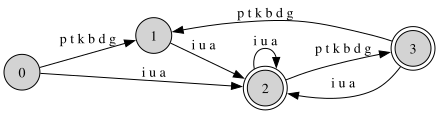

In [127]:
regex Word;
%dot

## Graphical output for a transducer
Devoicing transducer

In [128]:
define Devoi b -> p, d -> t, g -> k || _ .#. ;

redefined Devoi: 766 bytes. 3 states, 20 arcs, Cyclic.


1.0 kB. 5 states, 33 arcs, Cyclic.


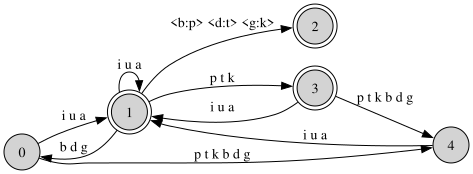

In [129]:
regex Word .o. Devoi;
%dot

## Apply up and apply down
Apply the network at the top of the stack downwards to a designated string.

In [130]:
apply down
bab

bap


To try another string, edit the foma cell and re-execute it.

Similarly for apply up. In this case there are two inputs related to the string 'bap'.

In [131]:
apply up
bap

bap
bab


## Other commands
In general, various Foma commands are expected to work, since the kernel passes a command to the Foma process, and displays the output. For instance here is the `pairs` command for a transducer.  The lines illustrate final devoicing for CVCVC inputs ending in `d` or `t`. For instance `pidud` is devoiced to `pidut`.

In [132]:
define R4 [Cons Vowel Cons Vowel [d | t]] .o. Word .o. Devoi;

redefined R4: 844 bytes. 6 states, 20 arcs, 648 paths.


In [133]:
regex R4;
pairs

844 bytes. 6 states, 20 arcs, 648 paths.
pipit	pipit
pipid	pipit
piput	piput
pipud	piput
pipat	pipat
pipad	pipat
pitit	pitit
pitid	pitit
pitut	pitut
pitud	pitut
pitat	pitat
pitad	pitat
pikit	pikit
pikid	pikit
pikut	pikut
pikud	pikut
pikat	pikat
pikad	pikat
pibit	pibit
pibid	pibit
pibut	pibut
pibud	pibut
pibat	pibat
pibad	pibat
pidit	pidit
pidid	pidit
pidut	pidut
pidud	pidut
pidat	pidat
pidad	pidat
pigit	pigit
pigid	pigit
pigut	pigut
pigud	pigut
pigat	pigat
pigad	pigat
pupit	pupit
pupid	pupit
puput	puput
pupud	puput
pupat	pupat
pupad	pupat
putit	putit
putid	putit
putut	putut
putud	putut
putat	putat
putad	putat
pukit	pukit
pukid	pukit
pukut	pukut
pukud	pukut
pukat	pukat
pukad	pukat
pubit	pubit
pubid	pubit
pubut	pubut
pubud	pubut
pubat	pubat
pubad	pubat
pudit	pudit
pudid	pudit
pudut	pudut
pudud	pudut
pudat	pudat
pudad	pudat
pugit	pugit
pugid	pugit
pugut	pugut
pugud	pugut
pugat	pugat
pugad	pugat
papit	papit
papid	papit
paput	paput
papud	paput
papat	papat
papad	papat
patit	patit
patid	patit

# Rule notation
Rule notations are a way of defining relations using substitutions constrained by context. This is the most common form.

redefined cap1: 512 bytes. 3 states, 10 arcs, Cyclic.
512 bytes. 3 states, 10 arcs, Cyclic.


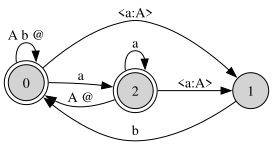

In [134]:
define cap1 a -> A || _ b;
regex cap1;
%dot

Above, a regular relation *cap* is first define. Then it is read onto the stack
with *regex*. Then the first network on the stack is displayed.

*Apply down* is used to test the relation.

In [135]:
apply down
abacab

AbacAb


### Apply up

In [136]:
apply up
AbacAb

abacab
abacAb
Abacab
AbacAb


Discuss: why are there multiple upper strings corresponding to the lower string
*AbacAb*?

### Composition of relations

redefined AtoE: 480 bytes. 2 states, 8 arcs, Cyclic.
740 bytes. 4 states, 21 arcs, Cyclic.


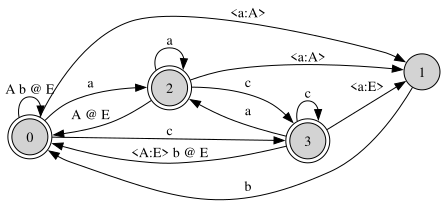

In [137]:
define AtoE A -> E || c _;
regex cap1 .o. AtoE;
%dot

In [138]:
apply down
abacab

AbacEb


We can think of the first and third *a* being capitalized into *A* by *cap1*, because they precede
*b*. Then the second *A* is transformed to *E* by *AtoE*, because it follows *c*. The following
defines the composed relation.  Relation composition is notated with `.o.`.  Note the periods.

In [139]:
define R1 cap1 .o. AtoE.

### Mapping a set
This defines sequences of *a*, *b*, *c* of length four.

In [140]:
define I4 [a | b | c]^{4,4};
regex I4;
print random-words

redefined R1: 712 bytes. 10 states, 25 arcs, 6561 paths.
473 bytes. 5 states, 12 arcs, 81 paths.
[1] bacb
[2] abcc
[1] acbc
[1] bcba
[1] accc
[1] bacc
[1] babb
[1] aacc
[1] abba
[1] bbac
[1] bbbc
[1] cccc
[1] acba
[1] aaac


This restricts `R1` to the set `I4` on the upper side, and collects the strings on
the lower side.  All the *a* that immediately precede *b* get capitalized.

In [141]:
define O4 [I4 .o. cap1].l;
regex O4;
print random-words

redefined O4: 810 bytes. 11 states, 26 arcs, 81 paths.
810 bytes. 11 states, 26 arcs, 81 paths.
[2] bccb
[1] cbbc
[1] ccac
[1] Abba
[1] cbbb
[1] aaaa
[1] cbaa
[2] Abcb
[2] Abca
[1] cccc
[1] cbac
[1] accc


In [142]:
define O4b [I4 .o. cap1 .o. AtoE].l;
regex O4b;
print random-words

redefined O4b: 964 bytes. 13 states, 34 arcs, 81 paths.
964 bytes. 13 states, 34 arcs, 81 paths.
[1] aacb
[1] ccaa
[1] bbbb
[1] caca
[1] bacc
[1] cbca
[1] Abbc
[1] accc
[1] cbcb
[1] cEbc
[1] Abcb
[1] Abcc
[1] acba
[1] bacb
[1] Abbb


### Order matters

In [143]:
define O4c [I4 .o. AtoE .o. cap1].l;
regex O4c;
print random-words

redefined O4c: 836 bytes. 11 states, 26 arcs, 81 paths.
836 bytes. 11 states, 26 arcs, 81 paths.
[1] aacb
[1] ccaa
[1] bbbb
[1] caca
[1] bacc
[1] cbca
[1] Abbc
[1] accc
[1] cbcb
[1] cAbc
[1] Abcb
[1] Abcc
[1] acba
[1] bacb
[1] Abbb


Discuss: why are there no *E*? 

Terminology: `cap1` feeds `AtoE`.

### Bleeding

In [144]:
define O4d [I4 .o. [b -> B || _ c]].l;

redefined O4d: 810 bytes. 11 states, 26 arcs, 81 paths.


In [145]:
regex O4d;
print random-words

810 bytes. 11 states, 26 arcs, 81 paths.
[1] Bccb
[1] ccBc
[1] bBcb
[1] cBcc
[1] Bccc
[1] aBcc
[1] bBcc
[2] bbbb
[1] acac
[1] cabb
[1] baBc
[1] cbbb
[1] ccab
[1] ccbb


In [146]:
define O4e [I4 .o. [b -> B || _ c] .o. cap1].l;
regex O4e;
print random-words

redefined O4e: 1.1 kB. 17 states, 44 arcs, 81 paths.
1.1 kB. 17 states, 44 arcs, 81 paths.
[1] aAbb
[2] Bccb
[1] cccc
[1] aBcc
[1] Bccc
[1] Bcba
[1] cAbb
[1] cbBc
[1] bAba
[1] cAba
[1] bBca
[1] acba
[1] ccBc
[1] AbBc


Discuss: *aBca*.

### Clean up the stack

In [147]:
clear

### Sourcing a file
The file should be in the directory where jupyter was launched.

In [148]:
source russian.fst

Opening file 'russian.fst'.
redefined VstemV: 880 bytes. 15 states, 17 arcs, 4 paths.
redefined VstemC: 1.7 kB. 29 states, 42 arcs, 15 paths.
redefined Vstem: 2.1 kB. 42 states, 59 arcs, 19 paths.
redefined Infl: 381 bytes. 4 states, 4 arcs, 2 paths.
redefined PHRASE: 1.2 kB. 4 states, 22 arcs, 38 paths.
redefined M: 2.3 kB. 43 states, 63 arcs, 22 paths.
redefined MOR: 2.6 kB. 43 states, 85 arcs, Cyclic.
redefined C: 835 bytes. 2 states, 15 arcs, 15 paths.
redefined LDrop: 1.4 kB. 4 states, 50 arcs, Cyclic.
redefined Devoi: 914 bytes. 3 states, 26 arcs, Cyclic.
redefined DSD: 635 bytes. 3 states, 16 arcs, Cyclic.
redefined PHON: 3.0 kB. 13 states, 150 arcs, Cyclic.
redefined Russian: 2.5 kB. 46 states, 68 arcs, 38 paths.
redefined Uword: 1.5 kB. 39 states, 56 arcs, 38 paths.
redefined Russian2: 1.8 kB. 43 states, 64 arcs, 38 paths.


### Russian verb example
#### Underlying word forms

In [149]:
regex Uword;

1.5 kB. 39 states, 56 arcs, 38 paths.


In [150]:
print random-words

[1] beregl
[3] sekl
[2] nesl
[1] skrebl
[2] mogl
[1] pletl
[1] obretla
[1] bredla
[1] govoril
[1] visel
[1] čital


#### Final *l* can drop.

In [151]:
regex PHON;

3.0 kB. 13 states, 150 arcs, Cyclic.


In [152]:
apply down
skrepl

skrep


But not always.

In [153]:
apply down
skrel

skrel


Definition from `russian.fst`.
```
define LDrop l -> 0 || C _ .#.;
```
It deletes a final *l* that follows a consonant.

In [199]:
regex C;
print words

835 bytes. 2 states, 15 arcs, 15 paths.
b
č
d
k
g
l
m
n
p
r
s
t
t'
v
z


### Variables and quoting

In [154]:
regex C;
print random-words

835 bytes. 2 states, 15 arcs, 15 paths.
[2] l
[4] z
[1] p
[3] r
[1] č
[2] g
[1] v
[1] t'


In [200]:
regex "C";
print random-words

202 bytes. 2 states, 1 arc, 1 path.
[15] C


In [201]:
regex %V;
print random-words

202 bytes. 2 states, 1 arc, 1 path.
[15] V


In [204]:
regex Vowel;
print words

329 bytes. 2 states, 3 arcs, 3 paths.
i
u
a


In [207]:
regex "Vowel";
print words

206 bytes. 2 states, 1 arc, 1 path.
Vowel


A symbol is treated as a variable, if that symbol has been defined as a variable. To
avoid that interpretation, quote the symbol.

In [157]:
print defined

Cons	455 bytes. 2 states, 6 arcs, 6 paths.
Russian2	1.8 kB. 43 states, 64 arcs, 38 paths.
Uword	1.5 kB. 39 states, 56 arcs, 38 paths.
Russian	2.5 kB. 46 states, 68 arcs, 38 paths.
PHON	3.0 kB. 13 states, 150 arcs, Cyclic.
DSD	635 bytes. 3 states, 16 arcs, Cyclic.
LDrop	1.4 kB. 4 states, 50 arcs, Cyclic.
C	835 bytes. 2 states, 15 arcs, 15 paths.
MOR	2.6 kB. 43 states, 85 arcs, Cyclic.
M	2.3 kB. 43 states, 63 arcs, 22 paths.
PHRASE	1.2 kB. 4 states, 22 arcs, 38 paths.
Infl	381 bytes. 4 states, 4 arcs, 2 paths.
Vstem	2.1 kB. 42 states, 59 arcs, 19 paths.
VstemC	1.7 kB. 29 states, 42 arcs, 15 paths.
VstemV	880 bytes. 15 states, 17 arcs, 4 paths.
O4e	1.1 kB. 17 states, 44 arcs, 81 paths.
O4d	810 bytes. 11 states, 26 arcs, 81 paths.
O4c	836 bytes. 11 states, 26 arcs, 81 paths.
O4b	964 bytes. 13 states, 34 arcs, 81 paths.
R1	712 bytes. 10 states, 25 arcs, 6561 paths.
O4	810 bytes. 11 states, 26 arcs, 81 paths.
I4	473 bytes. 5 states, 12 arcs, 81 paths.
AtoE	480 bytes. 2 states, 8 arcs, Cyclic

Clearing the stack does not affect definitions.  Beesley & Karttunen recommend making
heavy use of the stack, for instance popping it.  I use programs that are sequences
of definitions, using regex for demos.  

### Final consonants can devoice

In [158]:
regex Devoi;

914 bytes. 3 states, 26 arcs, Cyclic.


In [159]:
apply down
greb

grep


In [160]:
apply down
grez

gres


```
define Devoi b -> p, d -> t, g -> k, z -> s || _ .#.;
```

### Ldrop feeds Devoi

In [208]:
regex LDrop .o. Devoi;

2.0 kB. 6 states, 83 arcs, Cyclic.


In [209]:
apply down
grebl

grep


### Dental stop deletion
Delete certain consonants before *l*.
```
define DSD [t | d | t'] -> 0 || _ l;
```

In [210]:
regex DSD;

635 bytes. 3 states, 16 arcs, Cyclic.


In [211]:
apply down
gretle

grele


In [212]:
regex DSD .o. LDrop;

1.9 kB. 7 states, 80 arcs, Cyclic.


In [213]:
apply down
pletl

plel


In [214]:
apply down
plepl

plep


### Phonology for the language
The sound system as a whole has three rules composed in a certain order.
```
define PHON DSD .o. LDrop .o. Devoi;
```

In [221]:
regex PHON;

3.0 kB. 13 states, 150 arcs, Cyclic.


In [222]:
### Underlying words

In [223]:
regex Uword;
print words

1.5 kB. 39 states, 56 arcs, 38 paths.
govoril
govorila
grebl
grebla
pletl
pletla
pekl
pekla
pasl
pasla
pisal
pisala
čital
čitala
visel
visela
beregl
beregla
bredl
bredla
kladl
kladla
kradl
kradla
lezl
lezla
mogl
mogla
metl
metla
nesl
nesla
obretl
obretla
skrebl
skrebla
sekl
sekla


In [226]:
regex PHON;

3.0 kB. 13 states, 150 arcs, Cyclic.


Discuss: predict some surface words

In [230]:
apply down
skrebl

skrep


In [220]:
regex C;
print words

835 bytes. 2 states, 15 arcs, 15 paths.
b
č
d
k
g
l
m
n
p
r
s
t
t'
v
z


### Pairs
This shows the mapping for the entire set of underlying forms.

In [232]:
regex Uword .o. PHON;
pairs

1.8 kB. 43 states, 64 arcs, 38 paths.
govoril	govoril
govorila	govorila
grebl	grep
grebla	grebla
pletl	plel
pletla	plela
pekla	pekla
pekl	pek
pasla	pasla
pasl	pas
pisal	pisal
pisala	pisala
čital	čital
čitala	čitala
visel	visel
visela	visela
beregl	berek
beregla	beregla
bredl	brel
bredla	brela
kladl	klal
kladla	klala
kradl	kral
kradla	krala
lezl	les
lezla	lezla
mogl	mok
mogla	mogla
metl	mel
metla	mela
nesla	nesla
nesl	nes
obretl	obrel
obretla	obrela
skrebl	skrep
skrebla	skrebla
sekla	sekla
sekl	sek


### Relation as a machine

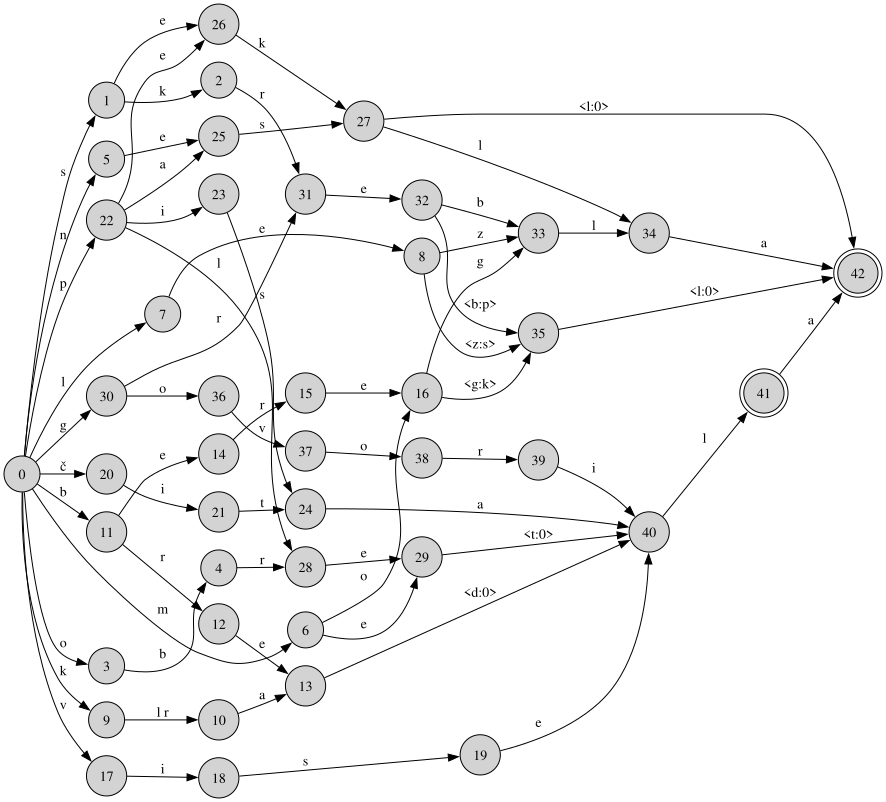

In [182]:
%dot

914 bytes. 3 states, 26 arcs, Cyclic.


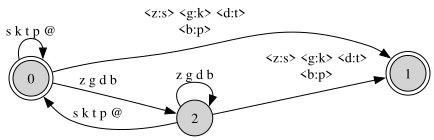

In [233]:
regex Devoi;
%dot

## Other rule notations
Devoice *g* before *k*.

In [234]:
define Dev g -> k || _ k;
regex Dev;

redefined Dev: 454 bytes. 3 states, 8 arcs, Cyclic.
454 bytes. 3 states, 8 arcs, Cyclic.


In [235]:
apply down
gggk

ggkk


Devoice *g* before a surface *k*.

In [196]:
define Dev2 g -> k \/ _ k;
regex Dev2;

redefined Dev2: 454 bytes. 3 states, 8 arcs, Cyclic.
454 bytes. 3 states, 8 arcs, Cyclic.


In [197]:
apply down
gggk

kkkk


In [198]:
apply down
gggg

gggg
